In [1]:
library('SelectSim')
library('tidyverse')
library('tictoc')
library('ggpubr')

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-conda-linux-gnu
Running under: AlmaLinux 9.3 (Shamrock Pampas Cat)

Matrix products: default
BLAS/LAPACK: /mnt/ndata/arvind/envs/selectsim_R/lib/libopenblasp-r0.3.29.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Zurich
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggpubr_0.6.0      tictoc_1.2.1      lubridate_1.9.4   forcats_1.0.0    
 [5] stringr_1.5.1     dplyr_1.1.4       purrr_1.0.4       readr_2.1.5      
 [9] tidyr_1.3.1       tibble_3.2.1      ggplot2_3.5.1     tidy

# MSK enrichmenet analysis 

In [3]:
msk_p_m_results <- readRDS(file='/mnt/ndata/arvind/co_mutation_project_revision/primary_met/results/msk_p_m_sampling_results_list.rds')
msk_m_results<-readRDS(file='/mnt/ndata/arvind/co_mutation_project_revision/primary_met/results/msk_m_sampling_results_list.rds')
msk_p_results<-readRDS(file='/mnt/ndata/arvind/co_mutation_project_revision/primary_met/results/msk_p_sampling_results_list.rds')

In [4]:
str(msk_p_results,max.level = 1)
str(msk_m_results,max.level = 1)
str(msk_p_m_results,max.level = 1)

List of 10
 $ :'data.frame':	31626 obs. of  23 variables:
 $ :'data.frame':	30628 obs. of  23 variables:
 $ :'data.frame':	28920 obs. of  23 variables:
 $ :'data.frame':	30628 obs. of  23 variables:
 $ :'data.frame':	30381 obs. of  23 variables:
 $ :'data.frame':	30876 obs. of  23 variables:
 $ :'data.frame':	29890 obs. of  23 variables:
 $ :'data.frame':	32385 obs. of  23 variables:
 $ :'data.frame':	31626 obs. of  23 variables:
 $ :'data.frame':	31125 obs. of  23 variables:
List of 10
 $ :'data.frame':	32896 obs. of  23 variables:
 $ :'data.frame':	31626 obs. of  23 variables:
 $ :'data.frame':	31878 obs. of  23 variables:
 $ :'data.frame':	31375 obs. of  23 variables:
 $ :'data.frame':	32131 obs. of  23 variables:
 $ :'data.frame':	31878 obs. of  23 variables:
 $ :'data.frame':	32896 obs. of  23 variables:
 $ :'data.frame':	32131 obs. of  23 variables:
 $ :'data.frame':	32131 obs. of  23 variables:
 $ :'data.frame':	32385 obs. of  23 variables:
List of 20
 $ :'data.frame':	31375 obs

In [5]:
for(i in c(1:10)){
    msk_p_results[[i]]<-msk_p_results[[i]] %>% mutate(id=case_when(SFE_1>SFE_2 ~paste(SFE_2,SFE_1,sep=" - "),
                        SFE_1<SFE_2 ~paste(SFE_1,SFE_2,sep=" - ")))
    msk_m_results[[i]]<-msk_m_results[[i]] %>% mutate(id=case_when(SFE_1>SFE_2 ~paste(SFE_2,SFE_1,sep=" - "),
                        SFE_1<SFE_2 ~paste(SFE_1,SFE_2,sep=" - ")))
}

In [6]:
for(i in c(1:20)){
    msk_p_m_results[[i]]<-msk_p_m_results[[i]] %>% mutate(id=case_when(SFE_1>SFE_2 ~paste(SFE_2,SFE_1,sep=" - "),
                        SFE_1<SFE_2 ~paste(SFE_1,SFE_2,sep=" - ")))
}

In [7]:
msk_p_m_results_cat1 <- list()
msk_p_m_results_cat2 <- list()
k=1
for(i in c(1:10)){
    msk_p_m_results_cat1[[k]]<- msk_p_m_results[[i]]
    msk_p_m_results_cat2[[k]]<- msk_p_m_results[[i+10]]
    k=k+1
}

In [8]:
str(msk_p_m_results_cat1,max.level = 1)
str(msk_p_m_results_cat2,max.level = 1)

List of 10
 $ :'data.frame':	31375 obs. of  24 variables:
 $ :'data.frame':	30381 obs. of  24 variables:
 $ :'data.frame':	31375 obs. of  24 variables:
 $ :'data.frame':	30381 obs. of  24 variables:
 $ :'data.frame':	32131 obs. of  24 variables:
 $ :'data.frame':	32896 obs. of  24 variables:
 $ :'data.frame':	31125 obs. of  24 variables:
 $ :'data.frame':	31375 obs. of  24 variables:
 $ :'data.frame':	32385 obs. of  24 variables:
 $ :'data.frame':	31375 obs. of  24 variables:
List of 10
 $ :'data.frame':	31626 obs. of  24 variables:
 $ :'data.frame':	31878 obs. of  24 variables:
 $ :'data.frame':	32640 obs. of  24 variables:
 $ :'data.frame':	30876 obs. of  24 variables:
 $ :'data.frame':	29403 obs. of  24 variables:
 $ :'data.frame':	31878 obs. of  24 variables:
 $ :'data.frame':	32131 obs. of  24 variables:
 $ :'data.frame':	31125 obs. of  24 variables:
 $ :'data.frame':	30381 obs. of  24 variables:
 $ :'data.frame':	30628 obs. of  24 variables:


In [9]:
list1 <- c(1:10)
list2 <- c(1:10)
combinations <- expand.grid(list1, list2)
unique_combinations <- combinations[combinations$Var1 < combinations$Var2, ]

In [10]:
unique_combinations %>% head()

,Var1,Var2
,<int>,<int>
11,1,2
21,1,3
22,2,3
31,1,4
32,2,4
33,3,4


In [11]:
fold_change_function <- function(combinations, msk_p_result, msk_m_result){
    fold_change_df <- list()
    fold_change_common_pairs <- list()
    obsered_fc<-c()
    for(i in c(1:nrow(combinations))){
        rows<-combinations[[i,1]]
        cols<-combinations[[i,2]]
        cat('--Running Combination',rows,' ',cols,'---\n')
        common_pairs <- unique(intersect(msk_p_result[[rows]]$id,msk_m_result[[cols]]$id))
        temp <- merge(msk_p_result[[rows]],msk_m_result[[cols]],by = 'id',suffixes = c('_primary','_met'))
        temp$FC <- log2((abs(temp$wES_met))/(abs(temp$wES_primary)))
        fold_change_df[[i]]<-temp
        significant_df <- temp %>% filter(FDR_primary==TRUE | FDR_met==TRUE)
        obsered_fc <- c(obsered_fc,significant_df$FC)
        fold_change_common_pairs[[i]]<-common_pairs
    }
    return(list('df'=fold_change_df,'pairs'=fold_change_common_pairs,'FC'=obsered_fc))
}

In [12]:
actual_fc_list <- fold_change_function(combinations = unique_combinations,msk_p_result = msk_p_results,msk_m_result = msk_m_results)

--Running Combination 1   2 ---
--Running Combination 1   3 ---
--Running Combination 2   3 ---
--Running Combination 1   4 ---
--Running Combination 2   4 ---
--Running Combination 3   4 ---
--Running Combination 1   5 ---
--Running Combination 2   5 ---
--Running Combination 3   5 ---
--Running Combination 4   5 ---
--Running Combination 1   6 ---
--Running Combination 2   6 ---
--Running Combination 3   6 ---
--Running Combination 4   6 ---
--Running Combination 5   6 ---
--Running Combination 1   7 ---
--Running Combination 2   7 ---
--Running Combination 3   7 ---
--Running Combination 4   7 ---
--Running Combination 5   7 ---
--Running Combination 6   7 ---
--Running Combination 1   8 ---
--Running Combination 2   8 ---
--Running Combination 3   8 ---
--Running Combination 4   8 ---
--Running Combination 5   8 ---
--Running Combination 6   8 ---
--Running Combination 7   8 ---
--Running Combination 1   9 ---
--Running Combination 2   9 ---
--Running Combination 3   9 ---
--Runnin

In [13]:
random_fc_list <- fold_change_function(combinations = unique_combinations,msk_p_result = msk_p_m_results_cat1,msk_m_result = msk_p_m_results_cat2)

--Running Combination 1   2 ---
--Running Combination 1   3 ---
--Running Combination 2   3 ---
--Running Combination 1   4 ---
--Running Combination 2   4 ---
--Running Combination 3   4 ---
--Running Combination 1   5 ---
--Running Combination 2   5 ---
--Running Combination 3   5 ---
--Running Combination 4   5 ---
--Running Combination 1   6 ---
--Running Combination 2   6 ---
--Running Combination 3   6 ---
--Running Combination 4   6 ---
--Running Combination 5   6 ---
--Running Combination 1   7 ---
--Running Combination 2   7 ---
--Running Combination 3   7 ---
--Running Combination 4   7 ---
--Running Combination 5   7 ---
--Running Combination 6   7 ---
--Running Combination 1   8 ---
--Running Combination 2   8 ---
--Running Combination 3   8 ---
--Running Combination 4   8 ---
--Running Combination 5   8 ---
--Running Combination 6   8 ---
--Running Combination 7   8 ---
--Running Combination 1   9 ---
--Running Combination 2   9 ---
--Running Combination 3   9 ---
--Runnin

In [14]:
consider_hits <- list()
consider_hit_df<-list()

In [15]:
for(i in c(1:45)){
   consider_hits[[i]]<-(actual_fc_list$df[[i]] %>% filter( FDR_primary==TRUE | FDR_met==TRUE))$id
   consider_hit_df[[i]]<-(actual_fc_list$df[[i]] %>% filter( FDR_primary==TRUE | FDR_met==TRUE)) %>% select(id,FC,wES_primary,wES_met,FDR_primary,FDR_met)
}

In [16]:
all_considered_hits <- unique(Reduce(union,consider_hits))

In [17]:
str(actual_fc_list,max.level = 1)

List of 3
 $ df   :List of 45
 $ pairs:List of 45
 $ FC   : num [1:13197] 0.2113 -2.8307 1.0348 0.4763 0.0617 ...


In [18]:
length(all_considered_hits)

[1] 508

In [19]:
filter_msk_p_result<-list()
filter_msk_m_result<-list()

In [20]:
for(i in c(1:10)){
    filter_msk_p_result[[i]]<-msk_p_results[[i]] %>% mutate(id=case_when(SFE_1>SFE_2 ~paste(SFE_2,SFE_1,sep=" - "),
                        SFE_1<SFE_2 ~paste(SFE_1,SFE_2,sep=" - "))) %>% filter(id %in% all_considered_hits)
    filter_msk_m_result[[i]]<-msk_m_results[[i]] %>% mutate(id=case_when(SFE_1>SFE_2 ~paste(SFE_2,SFE_1,sep=" - "),
                        SFE_1<SFE_2 ~paste(SFE_1,SFE_2,sep=" - ")))%>% filter(id %in% all_considered_hits)
}

In [21]:
merge_msk_p_result <- bind_rows(filter_msk_p_result)
rownames(merge_msk_p_result)<-c(1:nrow(merge_msk_p_result))
merge_msk_m_result <- bind_rows(filter_msk_m_result)
rownames(merge_msk_m_result)<-c(1:nrow(merge_msk_m_result))

In [22]:
df1<-merge_msk_p_result %>% select(id,sampling_run,wES) %>% pivot_wider(names_from = sampling_run,id_cols = id,values_from = wES)
df2<-merge_msk_m_result %>% select(id,sampling_run,wES) %>% pivot_wider(names_from = sampling_run,id_cols = id,values_from = wES)

In [23]:
df1$mean_nES<-rowMeans(df1[, !names(df1) %in% 'id'],na.rm = TRUE)
df2$mean_nES<-rowMeans(df2[, !names(df2) %in% 'id'],na.rm = TRUE)

In [24]:
dim(df1)
dim(df2)

[1] 508  12

[1] 508  12

In [25]:
plot_df <- data.frame('id'=(df1 %>% arrange(id))$id,'primary_wES'=(df1 %>% arrange(id))$mean_nES,'met_wES'=(df2 %>% arrange(id))$mean_nES)

In [26]:
actual_df <- plot_df

In [27]:
str(actual_fc_list,max.level = 1)

List of 3
 $ df   :List of 45
 $ pairs:List of 45
 $ FC   : num [1:13197] 0.2113 -2.8307 1.0348 0.4763 0.0617 ...


In [28]:
head(actual_df)

,id,primary_wES,met_wES
,<chr>,<dbl>,<dbl>
1,AKT1 - ARID1A,-1.110221,-2.103524
2,AKT1 - CTNNB1,2.569088,3.429756
3,AKT1 - ERBB2,-1.707102,-3.173532
4,AKT1 - GATA3,4.557416,1.347234
5,AKT1 - KRAS,-2.120833,-3.984023
6,AKT1 - MTOR,1.901743,2.076618


In [29]:
actual_df$FC <- log2(abs(actual_df$met_wES)/abs(actual_df$primary_wES))

In [30]:
head(actual_df)

,id,primary_wES,met_wES,FC
,<chr>,<dbl>,<dbl>,<dbl>
1,AKT1 - ARID1A,-1.110221,-2.103524,0.9219609
2,AKT1 - CTNNB1,2.569088,3.429756,0.4168496
3,AKT1 - ERBB2,-1.707102,-3.173532,0.8945402
4,AKT1 - GATA3,4.557416,1.347234,-1.7582150
5,AKT1 - KRAS,-2.120833,-3.984023,0.9095947
6,AKT1 - MTOR,1.901743,2.076618,0.1269137


In [31]:
filter_msk_p_result_cat1<-list()
filter_msk_m_result_cat2<-list()

In [32]:
for(i in c(1:10)){
    filter_msk_p_result_cat1[[i]]<-msk_p_m_results[[i]] %>% mutate(id=case_when(SFE_1>SFE_2 ~paste(SFE_2,SFE_1,sep=" - "),
                        SFE_1<SFE_2 ~paste(SFE_1,SFE_2,sep=" - ")))  
    filter_msk_m_result_cat2[[i]]<-msk_p_m_results[[i+10]] %>% mutate(id=case_when(SFE_1>SFE_2 ~paste(SFE_2,SFE_1,sep=" - "),
                        SFE_1<SFE_2 ~paste(SFE_1,SFE_2,sep=" - ")))
}

In [33]:
merge_msk_p_result_comb <- bind_rows(filter_msk_p_result_cat1)
rownames(merge_msk_p_result_comb)<-c(1:nrow(merge_msk_p_result_comb))
merge_msk_m_result_comb <- bind_rows(filter_msk_m_result_cat2)
rownames(merge_msk_m_result_comb)<-c(1:nrow(merge_msk_m_result_comb))

In [34]:
df1<-merge_msk_p_result_comb %>% select(id,sampling_run,wES) %>% pivot_wider(names_from = sampling_run,id_cols = id,values_from = wES)
df2<-merge_msk_m_result_comb %>% select(id,sampling_run,wES) %>% pivot_wider(names_from = sampling_run,id_cols = id,values_from = wES)

In [35]:
df1$mean_nES<-rowMeans(df1[, !names(df1) %in% 'id'],na.rm = FALSE)
df2$mean_nES<-rowMeans(df2[, !names(df2) %in% 'id'],na.rm = FALSE)

In [36]:
dim(df1)
dim(df2)

[1] 38036    12

[1] 38786    12

In [37]:
random_df <- data.frame('id'=(df1 %>% filter(id %in% actual_df$id)%>% arrange(id))$id,
                        'primary_wES'=(df1  %>% filter(id %in% actual_df$id) %>% arrange(id))$mean_nES,
                        'met_wES'=(df2 %>% filter(id %in% actual_df$id) %>% arrange(id))$mean_nES)

In [38]:
head(random_df)

,id,primary_wES,met_wES
,<chr>,<dbl>,<dbl>
1,AKT1 - ARID1A,-0.7599966,-1.140747
2,AKT1 - CTNNB1,2.4275444,2.314437
3,AKT1 - ERBB2,-2.2725333,-2.206715
4,AKT1 - GATA3,3.0219460,3.652205
5,AKT1 - KRAS,-2.5206748,-3.041396
6,AKT1 - MTOR,1.5207360,1.817709


In [39]:
random_df$FC <- log2(abs(random_df$met)/abs(random_df$primary))

In [40]:
head(random_df)

,id,primary_wES,met_wES,FC
,<chr>,<dbl>,<dbl>,<dbl>
1,AKT1 - ARID1A,-0.7599966,-1.140747,0.58591433
2,AKT1 - CTNNB1,2.4275444,2.314437,-0.06883664
3,AKT1 - ERBB2,-2.2725333,-2.206715,-0.04240097
4,AKT1 - GATA3,3.0219460,3.652205,0.27329000
5,AKT1 - KRAS,-2.5206748,-3.041396,0.27092354
6,AKT1 - MTOR,1.5207360,1.817709,0.25735124


In [41]:
dim(actual_df)
dim(random_df)

[1] 508   4

[1] 508   4

In [42]:
# Create a data frame
df <- data.frame(value =c(actual_df$FC,random_df$FC),
                 group = c(rep('Observed',508),rep('Expected',508)))

In [43]:
df

value,group
<dbl>,<chr>
0.92196085,Observed
0.41684955,Observed
0.89454016,Observed
-1.75821496,Observed
0.90959468,Observed
0.12691369,Observed
0.58214297,Observed
0.36872595,Observed
-3.24437216,Observed


In [44]:
ids <- actual_df$id

In [45]:
# Create a data frame
pair_df <- data.frame(pairs=ids,
                 background=(random_df%>%filter(id %in% ids))$FC,
                 actual=(actual_df%>%filter(id %in% ids))$FC)

In [46]:
head(pair_df)

,pairs,background,actual
,<chr>,<dbl>,<dbl>
1,AKT1 - ARID1A,0.58591433,0.9219609
2,AKT1 - CTNNB1,-0.06883664,0.4168496
3,AKT1 - ERBB2,-0.04240097,0.8945402
4,AKT1 - GATA3,0.27329000,-1.7582150
5,AKT1 - KRAS,0.27092354,0.9095947
6,AKT1 - MTOR,0.25735124,0.1269137


In [47]:
df <- data.frame(value =c(actual_df$FC,random_df$FC),
                 group = c(rep('Observed',508),rep('Expected',508)))

In [48]:
pair_df<-pair_df %>% mutate(diff=abs(abs(actual)-abs(background)))

In [49]:
summary(pair_df$diff)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
0.00057 0.20775 0.51424 0.97759 1.29878 7.16637       3 

In [50]:
msk_p_mat_df <-merge_msk_p_result %>% select(id,sampling_run,FDR) %>% pivot_wider(names_from = sampling_run,id_cols = id,values_from = FDR)
msk_m_mat_df <-merge_msk_m_result %>% select(id,sampling_run,FDR) %>% pivot_wider(names_from = sampling_run,id_cols = id,values_from = FDR)

In [51]:
sum_excluding <- rowSums(msk_p_mat_df[, !names(msk_p_mat_df) %in% 'id'],na.rm = TRUE)

In [52]:
msk_p_mat_df$count <-sum_excluding

In [53]:
sum_excluding <- rowSums(msk_m_mat_df[, !names(msk_m_mat_df) %in% 'id'],na.rm = TRUE)

In [54]:
msk_m_mat_df$count <-sum_excluding

In [55]:
head(pair_df)

,pairs,background,actual,diff
,<chr>,<dbl>,<dbl>,<dbl>
1,AKT1 - ARID1A,0.58591433,0.9219609,0.3360465
2,AKT1 - CTNNB1,-0.06883664,0.4168496,0.3480129
3,AKT1 - ERBB2,-0.04240097,0.8945402,0.8521392
4,AKT1 - GATA3,0.27329000,-1.7582150,1.4849250
5,AKT1 - KRAS,0.27092354,0.9095947,0.6386711
6,AKT1 - MTOR,0.25735124,0.1269137,0.1304376


In [56]:
df1<-merge_msk_p_result %>% select(id,sampling_run,wES) %>% pivot_wider(names_from = sampling_run,id_cols = id,values_from = wES)
df2<-merge_msk_m_result %>% select(id,sampling_run,wES) %>% pivot_wider(names_from = sampling_run,id_cols = id,values_from = wES)

In [57]:
df1$mean_nES<-rowMeans(df1[, !names(df1) %in% 'id'],na.rm = TRUE)
df2$mean_nES<-rowMeans(df2[, !names(df2) %in% 'id'],na.rm = TRUE)

In [58]:
dim(df1)
dim(df2)

[1] 508  12

[1] 508  12

In [59]:
plot_df <- data.frame('id'=(df1 %>% arrange(id))$id,'primary_wES'=(df1 %>% arrange(id))$mean_nES,'met_wES'=(df2 %>% arrange(id))$mean_nES)

In [60]:
head(plot_df)

,id,primary_wES,met_wES
,<chr>,<dbl>,<dbl>
1,AKT1 - ARID1A,-1.110221,-2.103524
2,AKT1 - CTNNB1,2.569088,3.429756
3,AKT1 - ERBB2,-1.707102,-3.173532
4,AKT1 - GATA3,4.557416,1.347234
5,AKT1 - KRAS,-2.120833,-3.984023
6,AKT1 - MTOR,1.901743,2.076618


In [61]:
msk_count_m <- msk_m_mat_df$count
names(msk_count_m)<-msk_m_mat_df$id
msk_count_p <- msk_p_mat_df$count
names(msk_count_p)<-msk_p_mat_df$id

In [62]:
plot_df<-plot_df %>% mutate(m_count =msk_count_m[id],p_count=msk_count_p[id])

In [63]:
head(plot_df)

,id,primary_wES,met_wES,m_count,p_count
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,AKT1 - ARID1A,-1.110221,-2.103524,0,1
2,AKT1 - CTNNB1,2.569088,3.429756,5,2
3,AKT1 - ERBB2,-1.707102,-3.173532,1,0
4,AKT1 - GATA3,4.557416,1.347234,0,9
5,AKT1 - KRAS,-2.120833,-3.984023,9,1
6,AKT1 - MTOR,1.901743,2.076618,1,3


In [64]:
diff_FC <- pair_df$diff
names(diff_FC)<-pair_df$pairs

In [65]:
FC_actual <- pair_df$actual
names(FC_actual)<-pair_df$pairs

FC_random <- pair_df$background
names(FC_random)<-pair_df$pairs

In [66]:
plot_df<-plot_df %>% mutate(diff=diff_FC[id],'FC_observed'=FC_actual[id],'FC_background'=FC_random[id])

In [67]:
head(plot_df)

,id,primary_wES,met_wES,m_count,p_count,diff,FC_observed,FC_background
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AKT1 - ARID1A,-1.110221,-2.103524,0,1,0.3360465,0.9219609,0.58591433
2,AKT1 - CTNNB1,2.569088,3.429756,5,2,0.3480129,0.4168496,-0.06883664
3,AKT1 - ERBB2,-1.707102,-3.173532,1,0,0.8521392,0.8945402,-0.04240097
4,AKT1 - GATA3,4.557416,1.347234,0,9,1.4849250,-1.7582150,0.27329000
5,AKT1 - KRAS,-2.120833,-3.984023,9,1,0.6386711,0.9095947,0.27092354
6,AKT1 - MTOR,1.901743,2.076618,1,3,0.1304376,0.1269137,0.25735124


In [68]:
# Distance Metric
plot_df<-plot_df %>% mutate(distance_observed = (met_wES-primary_wES)*(1/sqrt(2))) %>% arrange(desc(abs(distance_observed)))

In [69]:
head(plot_df)

,id,primary_wES,met_wES,m_count,p_count,diff,FC_observed,FC_background,distance_observed
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ESR1 - TP53,-5.648135,-42.171725,10,10,2.8592222,2.9004294,-0.041207267,-25.826078
2,EGFR - TP53,-9.419033,15.477661,10,8,0.3562612,0.7165366,0.360275331,17.604621
3,GATA3 - PIK3CA,-3.084611,-24.650765,10,1,2.7187655,2.9984717,-0.279706179,-15.249573
4,PIK3CA - TP53,-119.552666,-103.803093,10,10,0.2009333,-0.2037969,-0.002863618,11.136630
5,EGFR - RBM10,7.379633,-4.915655,6,9,0.3764018,-0.5861653,0.962567104,-8.694082
6,CBFB - PIK3CA,11.130105,-0.996175,0,10,3.3214672,-3.4819241,0.160456905,-8.574575


# Extracting Distance Cutoff to Decide enriched pairs

In [70]:
rnd<-msk_p_m_results
pset = c()
for(i in 1:10){

	temp = rnd[[i]]
	temp = temp[ temp$FDR, ]
	temp = temp[ , 'wES', drop = F]
	colnames(temp) = c(paste(c('wES_p',i), collapse = ""))
	
	if(i == 1){
		pset = temp
	} else {
		pset = merge(pset, temp, by = "row.names", all = TRUE)
		rownames(pset) = pset$Row.names
		pset = pset[,-1]
	}

}

mset = c()

for(i in 11:20){

	temp = rnd[[i]]
	temp = temp[ temp$FDR, ]
	temp = temp[ , 'wES', drop = F]
	colnames(temp) = c(paste(c('wES_m',i), collapse = ""))
	
	if(i == 11){
		mset = temp
	} else {
		mset = merge(mset, temp, by = "row.names", all = TRUE)
		rownames(mset) = mset$Row.names
		mset = mset[,-1]
	}

}

In [71]:
pset$primary_wES = apply(pset, 1, function (x) mean(x[!is.na(x)]))
mset$met_wES = apply(mset, 1, function (x) mean(x[!is.na(x)]))

set = merge(pset[,'primary_wES',drop = F], mset[,'met_wES',drop = F], by = 'row.names')
set$distance = (set$met_wES - set$primary_wES)*sin(pi/4)

In [72]:
set

Row.names,primary_wES,met_wES,distance
<I<chr>>,<dbl>,<dbl>,<dbl>
AKT1 - CBFB,3.440934,3.820489,0.2683857653
AKT1 - CTNNB1,4.164838,3.937410,-0.1608159783
AKT1 - GATA3,4.722523,5.227414,0.3570113169
AKT1 - KRAS,-3.764124,-4.016033,-0.1781264982
AKT1 - MTOR,3.229086,3.014181,-0.1519607197
AKT1 - PIK3CA,-21.238695,-20.899138,0.2401030969
AKT1 - PIK3R1,-4.264795,-3.405158,0.6078549788
AKT1 - PTEN,-6.829160,-7.316295,-0.3444561496
AKT1 - TP53,-11.558056,-12.273118,-0.5056253294


In [73]:
min_distance = sort(abs(set$distance))[ round(0.99*nrow(set)) ]
min_distance

[1] 2.018047

# Distane Cutoff selection : 
- Category of hits.
    - PM_enriched: Hits having distance cutoff `min_distance`
    - M_enriched: `m_count>=6 & p_count<=2`
    - P_enriched: `p_count>=6 & m_count<=2`
    - PM_switch:  `p_count>=6 & m_count>=6 & sign(met_wES*primary_wES)==-1`

In [74]:
pm<-plot_df
head(pm)

,id,primary_wES,met_wES,m_count,p_count,diff,FC_observed,FC_background,distance_observed
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ESR1 - TP53,-5.648135,-42.171725,10,10,2.8592222,2.9004294,-0.041207267,-25.826078
2,EGFR - TP53,-9.419033,15.477661,10,8,0.3562612,0.7165366,0.360275331,17.604621
3,GATA3 - PIK3CA,-3.084611,-24.650765,10,1,2.7187655,2.9984717,-0.279706179,-15.249573
4,PIK3CA - TP53,-119.552666,-103.803093,10,10,0.2009333,-0.2037969,-0.002863618,11.136630
5,EGFR - RBM10,7.379633,-4.915655,6,9,0.3764018,-0.5861653,0.962567104,-8.694082
6,CBFB - PIK3CA,11.130105,-0.996175,0,10,3.3214672,-3.4819241,0.160456905,-8.574575


In [75]:
min_sig  = 6
min_not = 2

pm$category = rep('selected', nrow = pm)
pm$category[ abs(pm$distance) > min_distance ] = 'PM_enriched'
pm$category[ abs(pm$distance) > min_distance & pm$p_count >= min_sig & pm$m_count <= min_not ] = 'P_specific'
pm$category[ abs(pm$distance) > min_distance & pm$m_count >= min_sig & pm$p_count <= min_not ] = 'M_specific'
pm$category[ abs(pm$distance) > min_distance & pm$m_count >= min_sig & pm$p_count >= min_sig & sign(pm$primary_wES*pm$met_wES) == -1 ] = 'PM_switch'

col = rep('gray70', nrow(pm))
col[ pm$category == 'PM_enriched' & abs(pm$primary_wES) < abs(pm$met_wES) ] = 'pink'
col[ pm$category == 'PM_enriched' & abs(pm$primary_wES) > abs(pm$met_wES) ] = 'lightblue'
col[ pm$category == 'P_specific' ] = 'blue'
col[ pm$category == 'M_specific' ] = 'red'
col[ pm$category == 'PM_switch' ] = 'darkgoldenrod1'

In [76]:
head(pm)

,id,primary_wES,met_wES,m_count,p_count,diff,FC_observed,FC_background,distance_observed,category
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,ESR1 - TP53,-5.648135,-42.171725,10,10,2.8592222,2.9004294,-0.041207267,-25.826078,PM_enriched
2,EGFR - TP53,-9.419033,15.477661,10,8,0.3562612,0.7165366,0.360275331,17.604621,PM_switch
3,GATA3 - PIK3CA,-3.084611,-24.650765,10,1,2.7187655,2.9984717,-0.279706179,-15.249573,M_specific
4,PIK3CA - TP53,-119.552666,-103.803093,10,10,0.2009333,-0.2037969,-0.002863618,11.136630,PM_enriched
5,EGFR - RBM10,7.379633,-4.915655,6,9,0.3764018,-0.5861653,0.962567104,-8.694082,PM_switch
6,CBFB - PIK3CA,11.130105,-0.996175,0,10,3.3214672,-3.4819241,0.160456905,-8.574575,P_specific


In [78]:
saveRDS(pm,file='../results/msk_p_m_fold_change_data_frame.rds')

In [79]:
max(abs(set$distance))
max(abs(pm$distance_observed))

[1] 6.239715

[1] 25.82608

In [102]:
distance_box_plot_df <- data.frame('data'=c(rep('observed',length(abs(pm$distance_observed))),
                                             rep('expected',length(abs(set$distance)))),
                                   'distance'=c(abs(pm$distance_observed),abs(set$distance)))

In [103]:
head(distance_box_plot_df)

,data,distance
,<chr>,<dbl>
1,observed,25.826078
2,observed,17.604621
3,observed,15.249573
4,observed,11.136630
5,observed,8.694082
6,observed,8.574575


In [104]:
t.test(abs(pm$distance_observed),abs(set$distance))$p.value

[1] 2.681807e-34

In [128]:
#distance_box_plot_df$x <- factor(distance_box_plot_df$data, levels = c('observed','expected'))
distance_box_plot_df$x <- factor(as.character(distance_box_plot_df$data), levels = c('expected','observed'))

In [129]:
head(distance_box_plot_df)

,data,distance,x
,<fct>,<dbl>,<fct>
1,observed,25.826078,observed
2,observed,17.604621,observed
3,observed,15.249573,observed
4,observed,11.136630,observed
5,observed,8.694082,observed
6,observed,8.574575,observed


In [146]:
options(repr.plot.width = 15, repr.plot.height = 5)
distance_box<-ggboxplot(data=distance_box_plot_df %>% arrange(x),
          x='x',
          y='distance',
          add = "dotplot",
          add.params=list('binwidth'=0.05))+
labs(title = "Metastasis vs Primary  absolute ES difference",x="",y="")+
theme_pubr(base_size = 24)+
#stat_compare_means(method = "t.test",label.y = 10,label.x = 0.5)+
geom_hline(yintercept = min_distance,linetype=2,color='red')+
theme(plot.title = element_text(hjust = 0.5))+coord_flip()+
scale_y_continuous(
    name = NULL,  # removes bottom axis label
    breaks = NULL,  # removes bottom axis ticks
    limits=c(0,30),
    sec.axis = dup_axis(
      #name = "X Axis (top)",
      breaks = seq(0, 30, by = 5)
    )
  )+
  theme(
    axis.title.x.bottom = element_blank(),
    axis.text.x.bottom = element_blank(),
    axis.ticks.x.bottom = element_blank(),

    axis.title.x.top = element_text(),
    axis.text.x.top = element_text(),
    axis.ticks.x.top = element_line()
  )


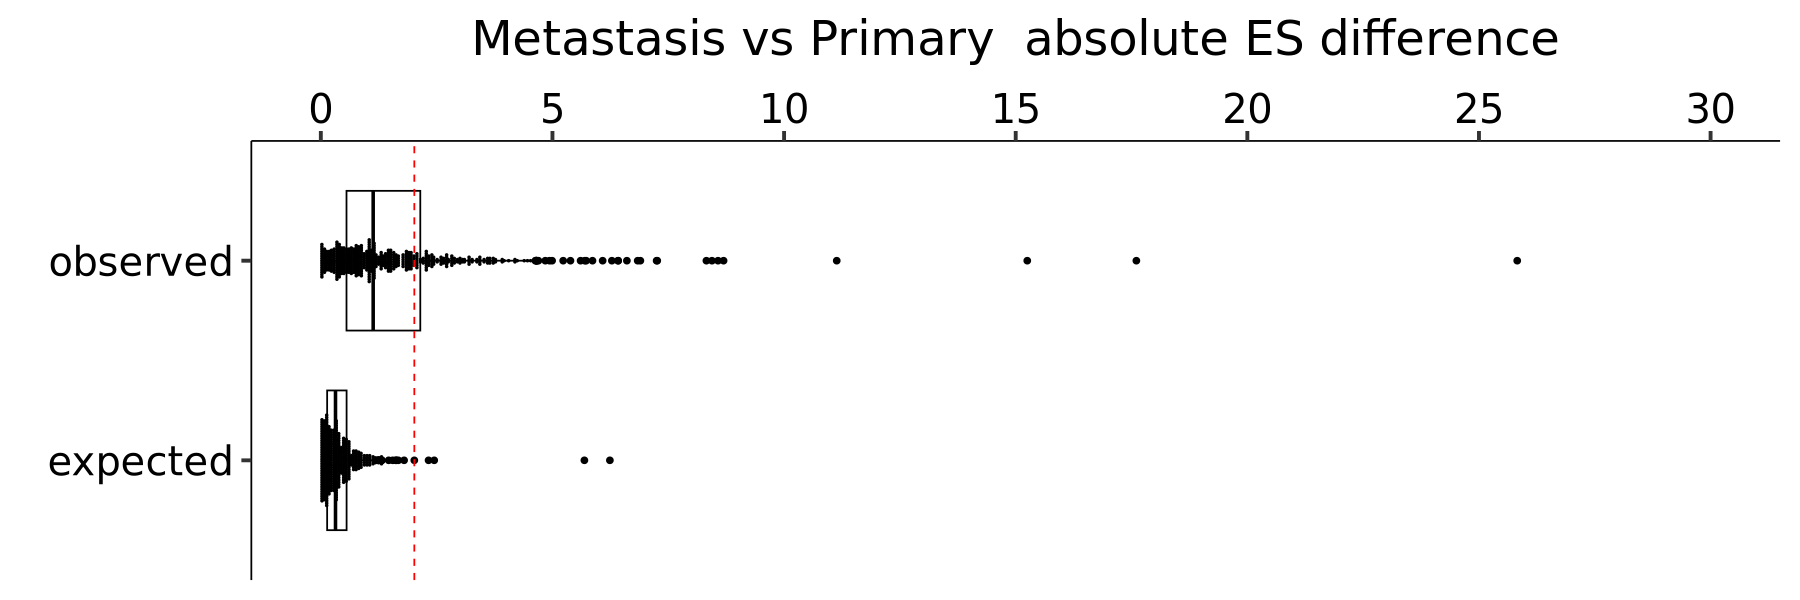

In [147]:
distance_box

In [114]:
ggsave(plot =distance_box ,filename = '../figures/msk_distance_boxplot_plot.png',height = 5,width = 10)

In [149]:
#ggsave(plot =distance_box ,filename = '../figures/msk_distance_boxplot_plot.pdf',height = 5,width = 10)
ggsave(plot =distance_box ,filename = '../figures/fig_3B_msk_distance_boxplot_plot.pdf',height = 5,width = 10)

In [150]:
saveRDS(distance_box,file='../figures/fig_3B_msk_distance_boxplot_data.rds')